# Disaster Tweet Classification

**Sprint 3 - NLP Text Classification Project**

**Author:** Alberto Diaz Durana  
**Date:** 2026-01-26

## Objective

Classify tweets as disaster-related (1) or non-disaster (0) using NLP techniques.

## Dataset

- **Source:** Kaggle NLP Getting Started competition
- **Size:** ~10,000 labeled tweets
- **Task:** Binary classification

## Notebook Structure

1. Setup & Data Loading
2. Exploratory Data Analysis
3. Text Preprocessing
4. Vectorization
5. Modeling & Evaluation
6. Conclusions


In [1]:
# Cell 2 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from collections import Counter

# Display settings
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# NLTK downloads
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.3.3
numpy: 2.2.6


In [3]:
# Cell 3 - Load Data
df = pd.read_csv('../data/train.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())


Shape: (7613, 2)
Columns: ['text', 'target']
                                                                                                  text  \
0                                Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all   
1                                                               Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are being notified by officers. No other evacuation or...   
3                                    13,000 people receive #wildfires evacuation orders in California    
4             Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school    

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [4]:
# Cell 4 - Data Info
print(f"Missing values:\n{df.isnull().sum()}\n")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())


Missing values:
text      0
target    0
dtype: int64

Duplicates: 92

Target distribution:
target
0    4342
1    3271
Name: count, dtype: int64


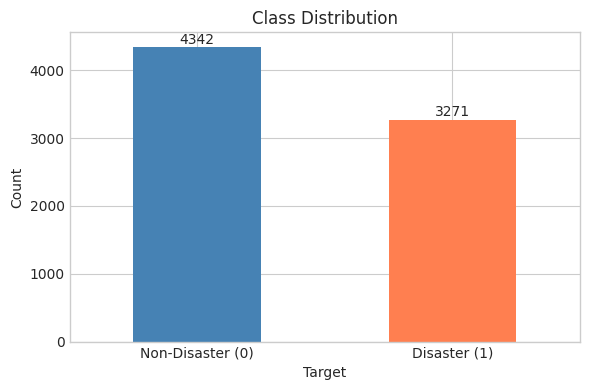

In [6]:
# Cell 5 - Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
ax.set_xticklabels(['Non-Disaster (0)', 'Disaster (1)'], rotation=0)

for i, v in enumerate(df['target'].value_counts()):
    ax.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()



In [7]:
# Cell 6 - Text Length Analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Text Length Statistics:")
print(df.groupby('target')[['text_length', 'word_count']].describe().round(1))


Text Length Statistics:
       text_length                                               word_count  \
             count   mean   std   min   25%    50%    75%    max      count   
target                                                                        
0           4342.0   95.7  35.9   7.0  68.0  101.0  130.0  157.0     4342.0   
1           3271.0  108.1  29.3  14.0  88.0  115.0  136.0  151.0     3271.0   

                                                
        mean  std  min   25%   50%   75%   max  
target                                          
0       14.7  6.2  1.0  10.0  15.0  19.0  31.0  
1       15.2  5.1  2.0  11.0  15.0  19.0  30.0  


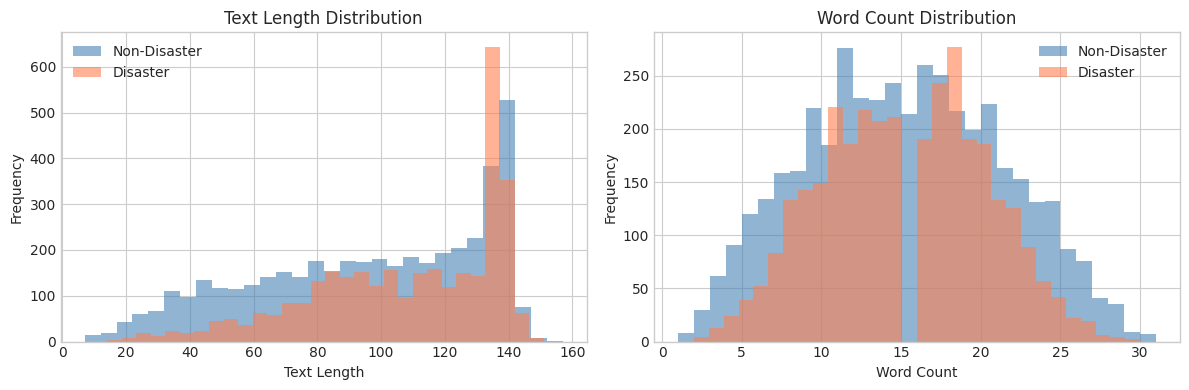

In [8]:
# Cell 7 - Text Length Distribution by Class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(['text_length', 'word_count']):
    for target, label, color in [(0, 'Non-Disaster', 'steelblue'), (1, 'Disaster', 'coral')]:
        axes[i].hist(df[df['target'] == target][col], bins=30, alpha=0.6, label=label, color=color)
    axes[i].set_xlabel(col.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[0].set_title('Text Length Distribution')
axes[1].set_title('Word Count Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/text_length_distribution.png', dpi=150)
plt.show()


### Initial Observations

**Class Distribution:**
- Slight imbalance: 57% non-disaster vs 43% disaster
- Not severe enough to require resampling techniques
- Will use stratified split and monitor F1-score (not just accuracy)

**Text Characteristics:**
- Disaster tweets slightly longer (mean: 108 chars) than non-disaster (96 chars)
- Word count nearly identical (~15 words per tweet)
- High overlap in distributions - text length alone not discriminative

**Implications for Modeling:**
- Length features unlikely to be strong predictors
- Classification will depend on actual word content/meaning
- Need to examine what words/patterns differentiate the classes


In [9]:
# Cell 9 - Sample Tweets by Class
print("=== DISASTER TWEETS (target=1) ===\n")
for i, text in enumerate(df[df['target'] == 1]['text'].sample(5, random_state=42)):
    print(f"{i+1}. {text}\n")

print("\n=== NON-DISASTER TWEETS (target=0) ===\n")
for i, text in enumerate(df[df['target'] == 0]['text'].sample(5, random_state=42)):
    print(f"{i+1}. {text}\n")


=== DISASTER TWEETS (target=1) ===

1. Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa

2. Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C

3. @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &amp; ruining this nation.

4. Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)

5. LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER


=== NON-DISASTER TWEETS (target=0) ===

1. Everyday is a near death fatality for me on the road. Thank god is on my side.??

2. #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk

3. @Lenn_Len Probably. We are inundated with them most years!

4. A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nPS3xpBKaQ

5. Next Man Up---AH SCREW THIS! I'm s

### Sample Tweet Analysis

**Disaster Tweets Characteristics:**
- Direct references to events: floods, fires, riots, attacks
- Often contain URLs (news links)
- Specific locations/numbers mentioned
- Factual/reporting tone

**Non-Disaster Tweets Characteristics:**
- Metaphorical use of disaster words: "near death", "hazard", "inundated", "void"
- Personal/emotional tone
- Casual language, humor, sarcasm

**Key Challenge:**
Words like "fatality", "hazard", "drowning" appear in BOTH classes. The model must learn **context**, not just keyword matching. This is why simple word frequency may have limitations.


In [10]:
# Cell 11 - Common Words by Class
# Let's look at common words/patterns in each class to understand what vocabulary differentiates them.
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = ' '.join(texts).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

disaster_words = get_top_words(df[df['target'] == 1]['text'])
non_disaster_words = get_top_words(df[df['target'] == 0]['text'])

print("TOP 20 WORDS - DISASTER TWEETS:")
for word, count in disaster_words:
    print(f"  {word}: {count}")

print("\nTOP 20 WORDS - NON-DISASTER TWEETS:")
for word, count in non_disaster_words:
    print(f"  {word}: {count}")


TOP 20 WORDS - DISASTER TWEETS:
  fire: 151
  via: 117
  suicide: 103
  disaster: 97
  police: 94
  people: 93
  killed: 92
  like: 91
  california: 88
  families: 81
  two: 71
  storm: 71
  train: 71
  bomb: 67
  emergency: 66
  get: 66
  crash: 65
  one: 63
  nuclear: 63
  bombing: 63

TOP 20 WORDS - NON-DISASTER TWEETS:
  like: 250
  new: 163
  get: 161
  one: 116
  body: 106
  via: 97
  would: 94
  love: 85
  got: 82
  people: 81
  full: 81
  see: 79
  know: 78
  video: 76
  back: 75
  emergency: 75
  going: 73
  still: 70
  time: 69
  want: 65


### Word Frequency Analysis

**Strong Disaster Indicators:**
- Event words: fire, disaster, storm, crash, bomb, bombing, nuclear
- Consequence words: killed, suicide, emergency, police
- Location specificity: california

**Non-Disaster Patterns:**
- Casual language: like, love, want, got, going
- Media/content: video, new, body, full
- Personal tone: would, know, see, back

**Overlapping Words (potential confusion):**
- "emergency" appears in both classes (66 vs 75)
- "like", "people", "via", "get" - common in both

**Implication:**
TF-IDF should help downweight common words and emphasize distinguishing terms like "killed", "bomb", "crash" for disasters.


In [11]:
# Cell 13 - Special Patterns (URLs, Mentions, Hashtags)
df['has_url'] = df['text'].str.contains(r'http\S+', regex=True).astype(int)
df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True).astype(int)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True).astype(int)

pattern_cols = ['has_url', 'has_mention', 'has_hashtag']

print("Pattern Frequency by Class:\n")
print(df.groupby('target')[pattern_cols].mean().round(3))
print(f"\nTotal tweets with URLs: {df['has_url'].sum()} ({df['has_url'].mean()*100:.1f}%)")
print(f"Total tweets with mentions: {df['has_mention'].sum()} ({df['has_mention'].mean()*100:.1f}%)")
print(f"Total tweets with hashtags: {df['has_hashtag'].sum()} ({df['has_hashtag'].mean()*100:.1f}%)")


Pattern Frequency by Class:

        has_url  has_mention  has_hashtag
target                                   
0         0.414        0.309        0.204
1         0.664        0.204        0.262

Total tweets with URLs: 3971 (52.2%)
Total tweets with mentions: 2009 (26.4%)
Total tweets with hashtags: 1743 (22.9%)


### Special Patterns Analysis

| Pattern | Non-Disaster | Disaster | Insight |
|---------|-------------|----------|---------|
| URLs | 41% | 66% | Disaster tweets more likely share news links |
| Mentions | 31% | 20% | Non-disaster more conversational (@replies) |
| Hashtags | 20% | 26% | Slightly more in disaster tweets |

**Preprocessing Decisions:**
- **URLs:** Remove - no semantic value, just noise
- **Mentions (@user):** Remove - user names not predictive
- **Hashtags:** Keep text, remove # symbol - hashtag content may be informative (#earthquake, #wildfire)


## 2. Business Understanding

### Problem Context

**Why does this matter?**

Identifying disaster-related tweets in real-time enables:
- Emergency responders to detect events faster
- News organizations to verify breaking stories
- Aid organizations to coordinate relief efforts

**The Challenge:**

Not all tweets containing disaster words are about actual disasters:
- "My inbox is a disaster" (metaphorical)
- "That party was fire!" (slang)
- "I'm dying of laughter" (exaggeration)

The model must distinguish **literal disaster reports** from **figurative language**.


### Day 1 Summary: Key Findings

**Dataset:**
- 7,613 tweets (57% non-disaster, 43% disaster)
- No missing values, 92 duplicates
- Clean binary classification task

**Text Characteristics:**
- Similar length/word count between classes
- Disaster tweets: more URLs, fewer mentions, factual tone
- Non-disaster: more conversational, metaphorical language

**Vocabulary Insights:**
- Strong disaster signals: killed, bomb, crash, fire, storm, nuclear
- Overlapping words exist: emergency, people, like
- Context matters more than keywords alone

**Preprocessing Strategy (for Day 2):**
1. Remove URLs and mentions
2. Keep hashtag text (remove # symbol)
3. Lowercase, remove punctuation
4. Remove stopwords
5. Apply lemmatization (preserve word meaning)
6. Use TF-IDF vectorization


## 3. Text Preprocessing

Clean and normalize tweet text based on EDA findings:
1. Remove URLs (no semantic value)
2. Remove mentions (@user)
3. Remove hashtag symbols (keep text)
4. Lowercase
5. Remove punctuation and special characters
6. Remove stopwords
7. Apply lemmatization


In [12]:
# Cell 18 - Preprocessing Function
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Preprocess tweet text:
    1. Remove URLs
    2. Remove mentions
    3. Remove hashtag symbols (keep text)
    4. Lowercase
    5. Remove punctuation/special chars
    6. Remove stopwords
    7. Lemmatize
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol (keep text)
    text = re.sub(r'#', '', text)
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    
    return ' '.join(tokens)

# Test on sample
sample = "Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all http://t.co/abc123"
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")


Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all http://t.co/abc123
Cleaned:  deed reason earthquake may allah forgive


In [13]:
# Cell 19 - Apply Preprocessing
df['text_clean'] = df['text'].apply(preprocess_text)

# Show before/after examples
print("BEFORE → AFTER PREPROCESSING:\n")
for i in [0, 100, 500, 1000]:
    print(f"[{i}] {df.loc[i, 'text'][:80]}...")
    print(f"    → {df.loc[i, 'text_clean'][:80]}")
    print()

print(f"Empty texts after preprocessing: {(df['text_clean'] == '').sum()}")


BEFORE → AFTER PREPROCESSING:

[0] Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all...
    → deed reason earthquake may allah forgive

[100] .@NorwayMFA #Bahrain police had previously died in a road accident they were not...
    → bahrain police previously died road accident killed explosion

[500] Christian Attacked by Muslims at the Temple Mount after Waving Israeli Flag via ...
    → christian attacked muslim temple mount waving israeli flag via pamela geller

[1000] #OVOFest Drake straight body bagging Meek on that OVO stage. #ZIPHIMUP!...
    → ovofest drake straight body bagging meek ovo stage ziphimup

Empty texts after preprocessing: 1


In [14]:
# Cell 20 - Handle Empty Texts
empty_idx = df[df['text_clean'] == ''].index
print(f"Empty text index: {empty_idx.tolist()}")
print(f"Original text: {df.loc[empty_idx, 'text'].values}")

# Replace empty with placeholder to avoid vectorization issues
df.loc[df['text_clean'] == '', 'text_clean'] = 'empty'
print(f"\nEmpty texts after fix: {(df['text_clean'] == '').sum()}")


Empty text index: [3663]
Original text: ['@Truly_Stings Yo Dm me']

Empty texts after fix: 0
